# ESC50 Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the ESC-50 dataset.

**Objectives:**
- Compare S4 vs LMU performance across different data sizes
- Analyze data efficiency (which model learns better with less data)
- Visualize learning curves and test metrics
- Identify the best model/fraction combination

**Fractions tested:** 10%, 25%, 50%, 100%


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Get project root
project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4


## Load Test Results

Load test_results.json from each run folder for both S4 and LMU models across all data fractions.


In [2]:
# Define run directories
runs_dir = Path.cwd() / "runs"

# Model configurations
models = ["s4", "lmu"]
fractions = [0.1, 0.25, 0.5, 1.0]

# Collect results
results = []

for model in models:
    for fraction in fractions:
        # Construct run name
        run_name = f"esc50_{model}_task"
        if fraction < 1.0:
            run_name += f"_frac_{fraction}"

        test_results_path = runs_dir / run_name / "test_results.json"

        if test_results_path.exists():
            with open(test_results_path, 'r') as f:
                test_data = json.load(f)

            results.append({
                'model': model.upper(),
                'fraction': fraction,
                'loss': test_data.get('loss'),
                'accuracy': test_data.get('accuracy'),
                'num_samples': test_data.get('num_samples'),
                'run_name': run_name
            })
            print(f"✓ Loaded {run_name}")
        else:
            print(f"✗ Missing {run_name}")

# Create DataFrame
df_results = pd.DataFrame(results)
print(f"\nLoaded {len(df_results)} results")
df_results


✓ Loaded esc50_s4_task_frac_0.1
✓ Loaded esc50_s4_task_frac_0.25
✓ Loaded esc50_s4_task_frac_0.5
✓ Loaded esc50_s4_task
✓ Loaded esc50_lmu_task_frac_0.1
✓ Loaded esc50_lmu_task_frac_0.25
✓ Loaded esc50_lmu_task_frac_0.5
✓ Loaded esc50_lmu_task

Loaded 8 results


,model,fraction,loss,accuracy,num_samples,run_name
0,S4,0.10,3.737729,0.1450,400,esc50_s4_task_frac_0.1
1,S4,0.25,3.307954,0.2575,400,esc50_s4_task_frac_0.25
2,S4,0.50,2.712792,0.4400,400,esc50_s4_task_frac_0.5
3,S4,1.00,2.179422,0.5600,400,esc50_s4_task
4,LMU,0.10,3.617465,0.1225,400,esc50_lmu_task_frac_0.1
5,LMU,0.25,3.260527,0.2050,400,esc50_lmu_task_frac_0.25
6,LMU,0.50,2.772718,0.3850,400,esc50_lmu_task_frac_0.5
7,LMU,1.00,2.470205,0.4950,400,esc50_lmu_task


## Results Summary Table


In [3]:
# Pivot table for better comparison
pivot_acc = df_results.pivot(index='fraction', columns='model', values='accuracy')
pivot_loss = df_results.pivot(index='fraction', columns='model', values='loss')

print("Test Accuracy by Model and Data Fraction:")
print(pivot_acc)
print("\nTest Loss by Model and Data Fraction:")
print(pivot_loss)

# Calculate improvement
if 'S4' in pivot_acc.columns and 'LMU' in pivot_acc.columns:
    pivot_acc['LMU_vs_S4'] = ((pivot_acc['LMU'] - pivot_acc['S4']) * 100).round(2)
    print("\nLMU vs S4 Accuracy Difference (percentage points):")
    print(pivot_acc['LMU_vs_S4'])

# Export to CSV
csv_path = Path("./comparison_results.csv")
df_results.to_csv(csv_path, index=False)
print(f"\nSaved to: {csv_path}")


Test Accuracy by Model and Data Fraction:
model        LMU      S4
fraction                
0.10      0.1225  0.1450
0.25      0.2050  0.2575
0.50      0.3850  0.4400
1.00      0.4950  0.5600

Test Loss by Model and Data Fraction:
model          LMU        S4
fraction                    
0.10      3.617465  3.737729
0.25      3.260527  3.307954
0.50      2.772718  2.712792
1.00      2.470205  2.179422

LMU vs S4 Accuracy Difference (percentage points):
fraction
0.10   -2.25
0.25   -5.25
0.50   -5.50
1.00   -6.50
Name: LMU_vs_S4, dtype: float64

Saved to: comparison_results.csv


## Visualization: Test Accuracy Comparison

Compare test accuracy of S4 and LMU across different data fractions.


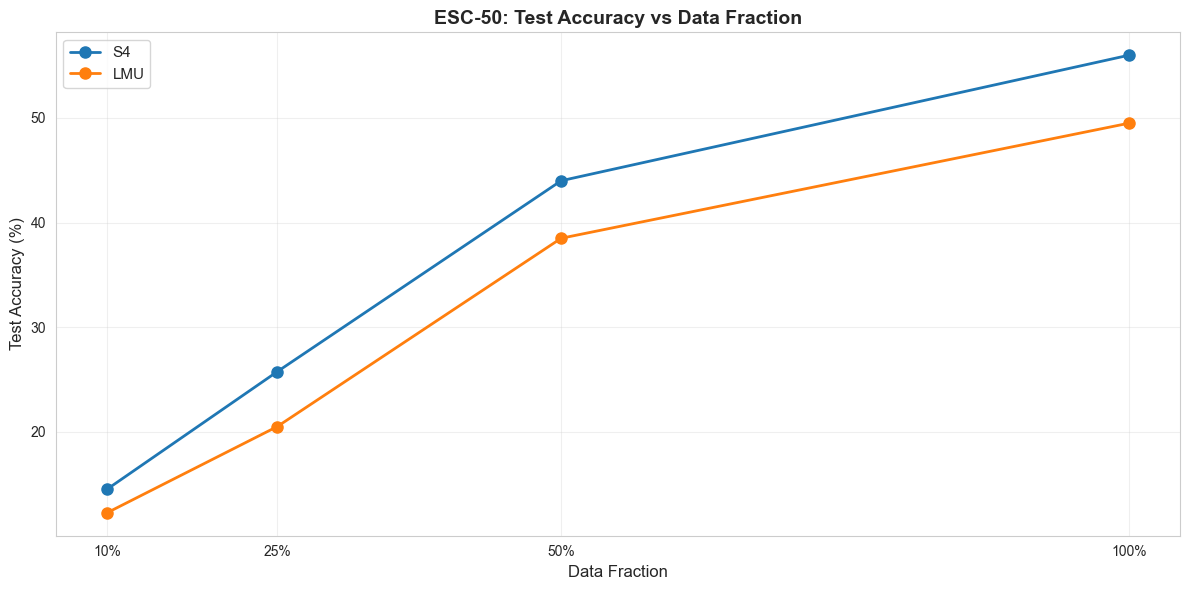

In [4]:
plt.figure(figsize=(12, 6))

for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model].sort_values('fraction')
    plt.plot(model_data['fraction'], model_data['accuracy'] * 100,
             marker='o', linewidth=2, markersize=8, label=model)

plt.xlabel('Data Fraction', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('ESC-50: Test Accuracy vs Data Fraction', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(fractions, [f'{int(f*100)}%' for f in fractions])
plt.tight_layout()
plt.show()


## Visualization: Test Loss Comparison

Compare test loss of S4 and LMU across different data fractions.


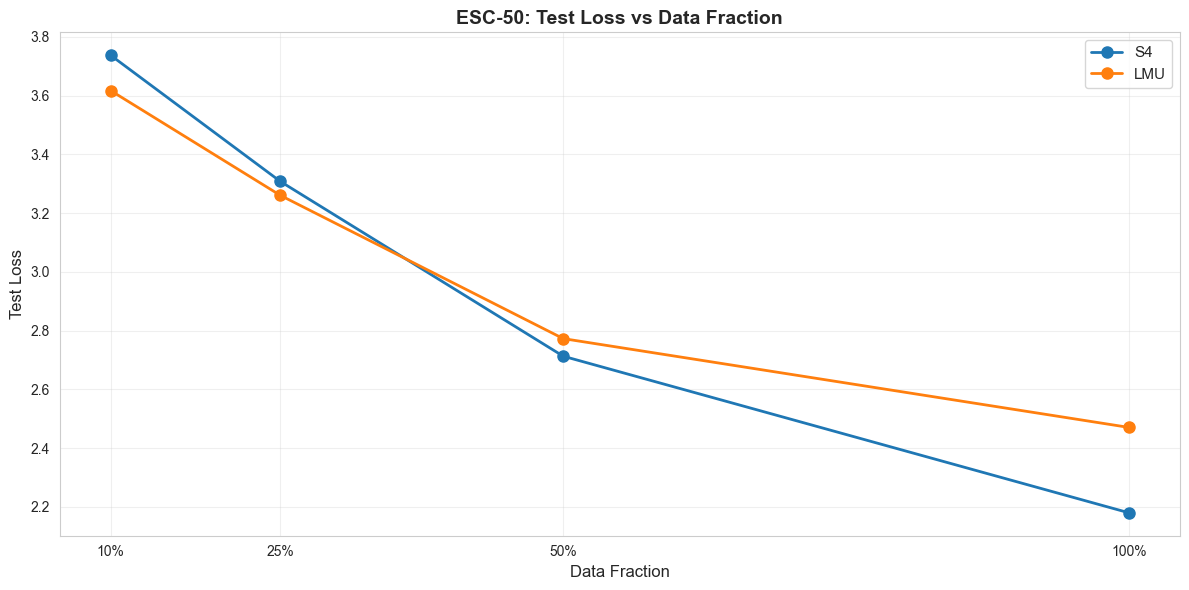

In [5]:
plt.figure(figsize=(12, 6))

for model in df_results['model'].unique():
    model_data = df_results[df_results['model'] == model].sort_values('fraction')
    plt.plot(model_data['fraction'], model_data['loss'],
             marker='o', linewidth=2, markersize=8, label=model)

plt.xlabel('Data Fraction', fontsize=12)
plt.ylabel('Test Loss', fontsize=12)
plt.title('ESC-50: Test Loss vs Data Fraction', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(fractions, [f'{int(f*100)}%' for f in fractions])
plt.tight_layout()
plt.show()


## Bar Chart Comparison

Side-by-side comparison of test accuracy for each data fraction.


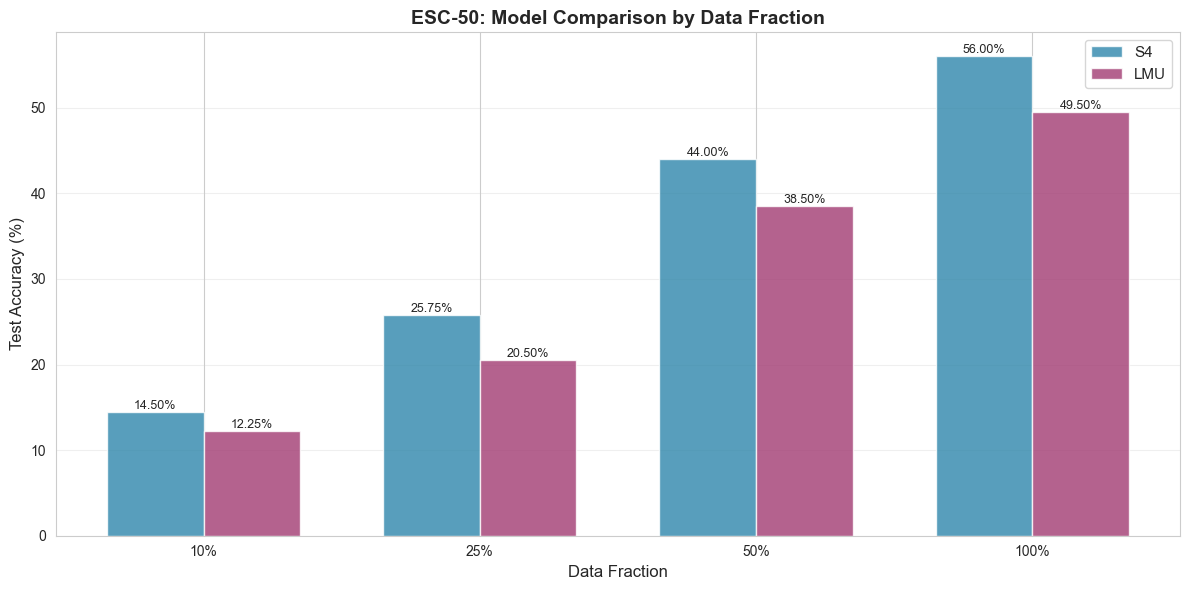

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(fractions))
width = 0.35

s4_data = df_results[df_results['model'] == 'S4'].sort_values('fraction')
lmu_data = df_results[df_results['model'] == 'LMU'].sort_values('fraction')

bars1 = ax.bar(x - width/2, s4_data['accuracy'] * 100, width,
               label='S4', alpha=0.8, color='#2E86AB')
bars2 = ax.bar(x + width/2, lmu_data['accuracy'] * 100, width,
               label='LMU', alpha=0.8, color='#A23B72')

ax.set_xlabel('Data Fraction', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('ESC-50: Model Comparison by Data Fraction', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{int(f*100)}%' for f in fractions])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## Data Efficiency Analysis

Analyze how efficiently each model learns with different amounts of data.


In [7]:
efficiency_data = []

for model in models:
    model_data = df_results[df_results['model'] == model.upper()].sort_values('fraction')
    accuracies = model_data['accuracy'].values

    for i in range(1, len(accuracies)):
        data_increase = fractions[i] - fractions[i-1]
        acc_increase = (accuracies[i] - accuracies[i-1]) * 100
        efficiency = acc_increase / data_increase

        efficiency_data.append({
            'model': model.upper(),
            'from_fraction': fractions[i-1],
            'to_fraction': fractions[i],
            'data_increase': f"{int(data_increase*100)}%",
            'acc_increase': f"{acc_increase:.2f}%",
            'efficiency': f"{efficiency:.2f}"
        })

df_efficiency = pd.DataFrame(efficiency_data)
print("Data Efficiency: Accuracy Gain per Unit of Additional Data")
print(df_efficiency.to_string(index=False))


Data Efficiency: Accuracy Gain per Unit of Additional Data
model  from_fraction  to_fraction data_increase acc_increase efficiency
   S4           0.10         0.25           15%       11.25%      75.00
   S4           0.25         0.50           25%       18.25%      73.00
   S4           0.50         1.00           50%       12.00%      24.00
  LMU           0.10         0.25           15%        8.25%      55.00
  LMU           0.25         0.50           25%       18.00%      72.00
  LMU           0.50         1.00           50%       11.00%      22.00


## Visualization: Data Efficiency

Plot efficiency scores showing which model gains more accuracy per unit of additional data.


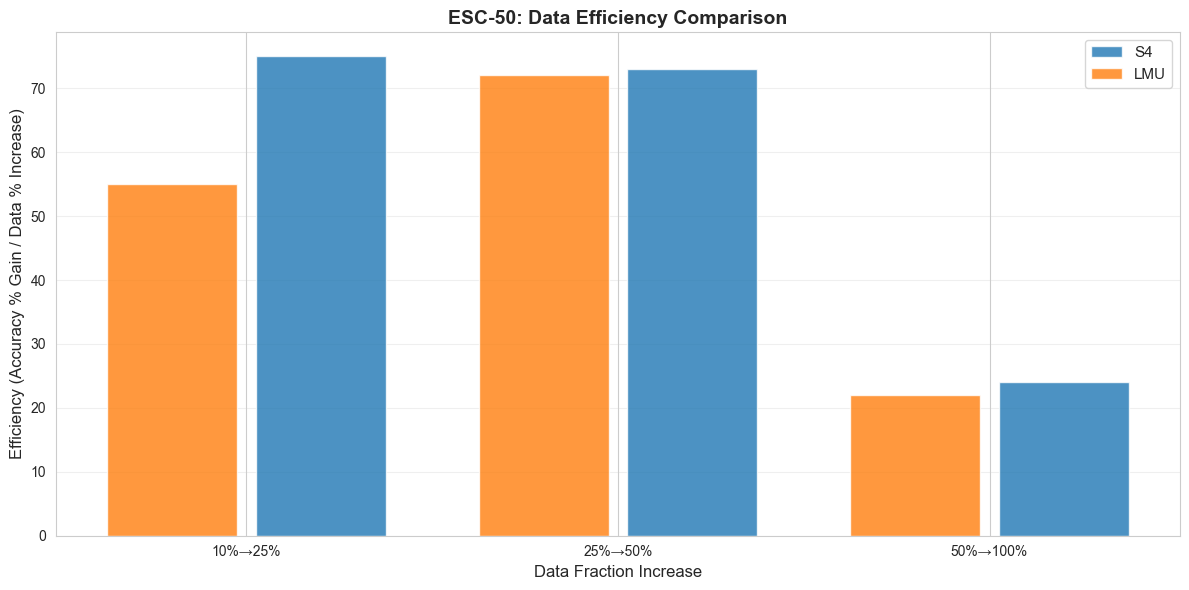

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

# Get x_labels from first model for consistent labeling
x_labels = []
for model in models:
    model_eff = [e for e in efficiency_data if e['model'] == model.upper()]
    if not x_labels:
        x_labels = [f"{e['from_fraction']:.0%}→{e['to_fraction']:.0%}" for e in model_eff]
    efficiencies = [float(e['efficiency']) for e in model_eff]

    x_pos = np.arange(len(efficiencies))
    offset = 0.2 if model == 's4' else -0.2
    ax.bar(x_pos + offset, efficiencies, width=0.35,
           label=model.upper(), alpha=0.8)

ax.set_xlabel('Data Fraction Increase', fontsize=12)
ax.set_ylabel('Efficiency (Accuracy % Gain / Data % Increase)', fontsize=12)
ax.set_title('ESC-50: Data Efficiency Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()


## Summary Statistics

Key insights from the comparison.


In [9]:
print("=" * 60)
print("ESC-50 MODEL COMPARISON SUMMARY")
print("=" * 60)
print()

# Best overall performance
best_overall = df_results.loc[df_results['accuracy'].idxmax()]
print(f"Best Overall Performance:")
print(f"  Model: {best_overall['model']}")
print(f"  Data Fraction: {int(best_overall['fraction']*100)}%")
print(f"  Accuracy: {best_overall['accuracy']*100:.2f}%")
print(f"  Loss: {best_overall['loss']:.4f}")
print()

# Performance at 100% data
print("Performance at 100% Data:")
full_data = df_results[df_results['fraction'] == 1.0].sort_values('accuracy', ascending=False)
for _, row in full_data.iterrows():
    print(f"  {row['model']}: {row['accuracy']*100:.2f}% accuracy, {row['loss']:.4f} loss")
print()

# Performance at 10% data (data efficiency)
print("Performance at 10% Data (Data Efficiency):")
small_data = df_results[df_results['fraction'] == 0.1].sort_values('accuracy', ascending=False)
for _, row in small_data.iterrows():
    print(f"  {row['model']}: {row['accuracy']*100:.2f}% accuracy, {row['loss']:.4f} loss")
print()

# Winner per fraction
print("Winner by Data Fraction:")
for fraction in fractions:
    frac_data = df_results[df_results['fraction'] == fraction].sort_values('accuracy', ascending=False)
    if len(frac_data) > 0:
        winner = frac_data.iloc[0]
        print(f"  {int(fraction*100):3d}%: {winner['model']} ({winner['accuracy']*100:.2f}% accuracy)")

print()
print("=" * 60)


ESC-50 MODEL COMPARISON SUMMARY

Best Overall Performance:
  Model: S4
  Data Fraction: 100%
  Accuracy: 56.00%
  Loss: 2.1794

Performance at 100% Data:
  S4: 56.00% accuracy, 2.1794 loss
  LMU: 49.50% accuracy, 2.4702 loss

Performance at 10% Data (Data Efficiency):
  S4: 14.50% accuracy, 3.7377 loss
  LMU: 12.25% accuracy, 3.6175 loss

Winner by Data Fraction:
   10%: S4 (14.50% accuracy)
   25%: S4 (25.75% accuracy)
   50%: S4 (44.00% accuracy)
  100%: S4 (56.00% accuracy)

